# CodeAlpha Data Analytics Internship Project

## Project Title
Airbnb Listings Market Analysis: Pricing, Availability, and Neighborhood Trends

## Tasks Completed
- Task 2: Exploratory Data Analysis
- Task 3: Data Visualization

## Dataset
This project uses Airbnb listings data from Inside Airbnb. The analysis focuses on listing prices, room types, neighborhoods, availability, review activity, and host behavior.

## Project Objective
The goal of this project is to clean and analyze Airbnb listing data, identify important pricing and availability patterns, and create visualizations that communicate useful insights for market understanding and decision-making.

In [1]:
# Import the main libraries needed for data analysis and visualization

from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Make pandas outputs easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Make charts look cleaner
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

# File path for the dataset
# File path for the dataset
# The notebook first looks for the file in a local data folder.
# If not found, it looks in the same folder as the notebook.

if Path("data/listings.csv").exists():
    DATA_PATH = "data/listings.csv"
else:
    DATA_PATH = "listings.csv"

# Folder where charts will be saved
VISUALS_DIR = Path("visuals")
VISUALS_DIR.mkdir(exist_ok=True)

# Load the dataset
df = pd.read_csv(DATA_PATH)

# Standardize column names to make them easier to work with
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

display(Markdown("### Dataset Loaded Successfully"))

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

### Dataset Loaded Successfully

Rows: 490
Columns: 19


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2992450,Luxury 2 bedroom apartment,4621559,1462661762635155041,Kenneth,NaN,THIRD WARD,42.66,-73.75,Entire home/apt,80.00,28.00,9,2022-08-17,0.06,1,77,0,NaN
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.65,-73.77,Entire home/apt,211.00,1.00,317,2026-01-25,2.20,7,328,8,NaN
2,5651579,Large studio apt by Capital Center & ESP@,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.65,-73.76,Entire home/apt,97.00,1.00,406,2026-06-12,3.00,2,25,37,NaN
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.65,-73.77,Entire home/apt,160.00,1.00,332,2025-06-30,2.47,7,359,1,NaN
4,9501054,Spacious suite with full bath by Capital Center,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.65,-73.76,Private room,86.00,1.00,469,2026-06-09,3.71,2,235,47,NaN


In [2]:
# Initial inspection of the dataset

display(Markdown("## Initial Data Inspection"))

# Create a column-level report showing data types, missing values, and unique values
column_report = pd.DataFrame({
    "column": df.columns,
    "data_type": [str(dtype) for dtype in df.dtypes],
    "missing_values": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
}).sort_values("missing_percent", ascending=False)

display(Markdown("### Column Quality Report"))
display(column_report)

display(Markdown("### Summary Statistics"))
display(df.describe(include="all").T)

## Initial Data Inspection

### Column Quality Report

,column,data_type,missing_values,missing_percent,unique_values
5,neighbourhood_group,float64,490,100.00,0
18,license,float64,490,100.00,0
14,reviews_per_month,float64,60,12.24,253
13,last_review,object,60,12.24,196
10,price,float64,32,6.53,228
11,minimum_nights,float64,1,0.20,22
0,id,int64,0,0.00,490
2,host_id,int64,0,0.00,186
1,name,object,0,0.00,489
4,host_name,object,0,0.00,169


### Summary Statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,490.00,NaN,NaN,NaN,"961,754,887,763,929,984.00","580,083,733,193,505,024.00","2,992,450.00","690,491,482,540,526,848.00","1,112,066,972,991,066,112.00","1,458,294,607,708,536,064.00","1,701,482,737,257,369,600.00"
name,490,489,Large Bedroom in the heart of downtown Albany.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,490.00,NaN,NaN,NaN,"6,840,568,713,538,563.00","106,962,314,407,833,600.00","649,068.00","47,625,981.00","232,967,878.00","466,790,114.00","1,676,922,675,439,893,504.00"
host_profile_id,490.00,NaN,NaN,NaN,"1,472,998,320,032,593,920.00","28,192,492,503,188,128.00","1,462,517,583,121,314,560.00","1,463,574,448,322,349,056.00","1,468,231,973,425,237,504.00","1,469,754,210,102,694,656.00","1,676,923,224,672,492,288.00"
host_name,490,169,⁨Premier Stay Co.⁩,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,490,15,SIXTH WARD,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,490.00,NaN,NaN,NaN,42.66,0.01,42.63,42.65,42.66,42.66,42.71
longitude,490.00,NaN,NaN,NaN,-73.78,0.02,-73.88,-73.79,-73.77,-73.76,-73.74
room_type,490,4,Entire home/apt,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Task 2: Exploratory Data Analysis

This section explores the Airbnb listings dataset before building visualizations.

## Main Questions
1. What is the overall structure of the dataset?
2. Which columns have missing values or data quality issues?
3. What are the most common room types?
4. Which neighborhoods have the most Airbnb listings?
5. Which neighborhoods have the highest average prices?
6. How do prices differ between room types?
7. How available are listings throughout the year?
8. Which hosts have the highest number of listings?
9. Are there outliers or unusual values in price, minimum nights, or availability?

In [3]:
# Data cleaning
# The goal is to prepare the dataset for analysis without accidentally deleting useful rows.

airbnb = df.copy()
starting_shape = airbnb.shape

# Remove duplicate rows
airbnb = airbnb.drop_duplicates()

# Remove duplicate listings based on listing ID, if the ID column exists
if "id" in airbnb.columns:
    airbnb = airbnb.drop_duplicates(subset=["id"])

# Drop columns that are completely empty
fully_empty_columns = airbnb.columns[airbnb.isna().all()].tolist()
airbnb = airbnb.drop(columns=fully_empty_columns)

# Make sure price exists
if "price" not in airbnb.columns:
    raise KeyError("The dataset must contain a price column.")

# Clean price values
# This works whether price is stored like "$1,200" or already stored as a number.
airbnb["price"] = (
    airbnb["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

airbnb["price"] = pd.to_numeric(airbnb["price"], errors="coerce")

# Convert numeric columns safely
numeric_columns = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "latitude",
    "longitude"
]

for col in numeric_columns:
    if col in airbnb.columns:
        airbnb[col] = pd.to_numeric(airbnb[col], errors="coerce")

# Convert date columns safely
if "last_review" in airbnb.columns:
    airbnb["last_review"] = pd.to_datetime(airbnb["last_review"], errors="coerce")

# Missing reviews_per_month usually means the listing has no review activity, so fill with 0
if "reviews_per_month" in airbnb.columns:
    airbnb["reviews_per_month"] = airbnb["reviews_per_month"].fillna(0)

# Fill missing minimum nights with the median valid value
if "minimum_nights" in airbnb.columns:
    valid_minimum_nights = airbnb.loc[airbnb["minimum_nights"] > 0, "minimum_nights"]
    median_minimum_nights = valid_minimum_nights.median()
    
    if pd.isna(median_minimum_nights):
        median_minimum_nights = 1
    
    airbnb["minimum_nights"] = airbnb["minimum_nights"].fillna(median_minimum_nights)

# Keep useful analysis columns only if they exist in the dataset
useful_columns = [
    "id",
    "name",
    "host_id",
    "host_name",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm"
]

available_columns = [col for col in useful_columns if col in airbnb.columns]
airbnb = airbnb[available_columns]

# Drop rows missing the key columns needed for analysis
required_columns = [col for col in ["price", "neighbourhood", "room_type"] if col in airbnb.columns]
airbnb = airbnb.dropna(subset=required_columns)

# Remove invalid price values
airbnb = airbnb[airbnb["price"] > 0]

# Keep valid availability values
if "availability_365" in airbnb.columns:
    airbnb = airbnb[
        (airbnb["availability_365"] >= 0) &
        (airbnb["availability_365"] <= 365)
    ]

# Keep valid minimum-night values
if "minimum_nights" in airbnb.columns:
    airbnb = airbnb[airbnb["minimum_nights"] >= 1]

# Remove extreme price outliers using the 99th percentile
before_outlier_removal = airbnb.shape[0]
price_cap = airbnb["price"].quantile(0.99)
airbnb = airbnb[airbnb["price"] <= price_cap]
outliers_removed = before_outlier_removal - airbnb.shape[0]

# Create availability categories for easier analysis
if "availability_365" in airbnb.columns:
    airbnb["availability_category"] = pd.cut(
        airbnb["availability_365"],
        bins=[-1, 0, 90, 180, 365],
        labels=[
            "Not available",
            "Low availability",
            "Medium availability",
            "High availability"
        ]
    )

# Create review activity categories
if "number_of_reviews" in airbnb.columns:
    airbnb["review_activity"] = pd.cut(
        airbnb["number_of_reviews"],
        bins=[-1, 0, 10, 50, np.inf],
        labels=[
            "No reviews",
            "Low review activity",
            "Medium review activity",
            "High review activity"
        ]
    )

# Create host type categories
if "calculated_host_listings_count" in airbnb.columns:
    airbnb["host_type"] = np.where(
        airbnb["calculated_host_listings_count"] > 1,
        "Multi-listing host",
        "Single-listing host"
    )

# Display cleaning summary
cleaning_summary = pd.DataFrame({
    "Step": [
        "Original dataset shape",
        "Columns dropped because they were fully empty",
        "Price cap used for outlier removal",
        "Extreme price rows removed",
        "Cleaned dataset shape"
    ],
    "Result": [
        str(starting_shape),
        ", ".join(fully_empty_columns) if fully_empty_columns else "None",
        f"${price_cap:,.2f}",
        outliers_removed,
        str(airbnb.shape)
    ]
})

display(Markdown("## Data Cleaning Summary"))
display(cleaning_summary)

display(Markdown("### Cleaned Dataset Preview"))
display(airbnb.head())

display(Markdown("### Cleaned Dataset Info"))
airbnb.info()

## Data Cleaning Summary

,Step,Result
0,Original dataset shape,"(490, 19)"
1,Columns dropped because they were fully empty,"neighbourhood_group, license"
2,Price cap used for outlier removal,$842.58
3,Extreme price rows removed,5
4,Cleaned dataset shape,"(453, 19)"


### Cleaned Dataset Preview

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,availability_category,review_activity,host_type
0,2992450,Luxury 2 bedroom apartment,4621559,Kenneth,THIRD WARD,42.66,-73.75,Entire home/apt,80.00,28.00,9,2022-08-17,0.06,1,77,0,Low availability,Low review activity,Single-listing host
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,Ming,SIXTH WARD,42.65,-73.77,Entire home/apt,211.00,1.00,317,2026-01-25,2.20,7,328,8,High availability,High review activity,Multi-listing host
2,5651579,Large studio apt by Capital Center & ESP@,29288920,Gregg,SECOND WARD,42.65,-73.76,Entire home/apt,97.00,1.00,406,2026-06-12,3.00,2,25,37,Low availability,High review activity,Multi-listing host
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,Ming,SIXTH WARD,42.65,-73.77,Entire home/apt,160.00,1.00,332,2025-06-30,2.47,7,359,1,High availability,High review activity,Multi-listing host
4,9501054,Spacious suite with full bath by Capital Center,29288920,Gregg,SECOND WARD,42.65,-73.76,Private room,86.00,1.00,469,2026-06-09,3.71,2,235,47,High availability,High review activity,Multi-listing host


### Cleaned Dataset Info

<class 'pandas.core.frame.DataFrame'>
Index: 453 entries, 0 to 489
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              453 non-null    int64         
 1   name                            453 non-null    object        
 2   host_id                         453 non-null    int64         
 3   host_name                       453 non-null    object        
 4   neighbourhood                   453 non-null    object        
 5   latitude                        453 non-null    float64       
 6   longitude                       453 non-null    float64       
 7   room_type                       453 non-null    object        
 8   price                           453 non-null    float64       
 9   minimum_nights                  453 non-null    float64       
 10  number_of_reviews               453 non-null    int64         
 11  last_review

In [4]:
# High-level overview after cleaning

display(Markdown("## Cleaned Dataset Overview"))

overview_metrics = pd.DataFrame({
    "Metric": [
        "Total listings after cleaning",
        "Total columns after cleaning",
        "Unique neighborhoods",
        "Unique room types",
        "Average price",
        "Median price",
        "Minimum price",
        "Maximum price",
        "Average availability per year"
    ],
    "Value": [
        f"{airbnb.shape[0]:,}",
        f"{airbnb.shape[1]:,}",
        f"{airbnb['neighbourhood'].nunique():,}" if "neighbourhood" in airbnb.columns else "N/A",
        f"{airbnb['room_type'].nunique():,}" if "room_type" in airbnb.columns else "N/A",
        f"${airbnb['price'].mean():,.2f}",
        f"${airbnb['price'].median():,.2f}",
        f"${airbnb['price'].min():,.2f}",
        f"${airbnb['price'].max():,.2f}",
        f"{airbnb['availability_365'].mean():,.2f} days" if "availability_365" in airbnb.columns else "N/A"
    ]
})

display(overview_metrics)

## Cleaned Dataset Overview

,Metric,Value
0,Total listings after cleaning,453
1,Total columns after cleaning,19
2,Unique neighborhoods,15
3,Unique room types,4
4,Average price,$165.62
5,Median price,$145.00
6,Minimum price,$13.00
7,Maximum price,$840.00
8,Average availability per year,252.31 days


In [5]:
# Check remaining missing values and numerical patterns

display(Markdown("## Missing Values After Cleaning"))

missing_after_cleaning = pd.DataFrame({
    "missing_values": airbnb.isna().sum(),
    "missing_percent": (airbnb.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing_after_cleaning[missing_after_cleaning["missing_values"] > 0])

display(Markdown("## Numerical Summary"))

numeric_analysis_columns = [
    col for col in [
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "availability_365",
        "number_of_reviews_ltm",
        "calculated_host_listings_count"
    ]
    if col in airbnb.columns
]

display(airbnb[numeric_analysis_columns].describe().T)

## Missing Values After Cleaning

,missing_values,missing_percent
last_review,55,12.14


## Numerical Summary

,count,mean,std,min,25%,50%,75%,max
price,453.00,165.62,109.01,13.00,89.00,145.00,208.00,840.00
minimum_nights,453.00,5.67,10.71,1.00,1.00,1.00,3.00,90.00
number_of_reviews,453.00,61.50,115.14,0.00,3.00,17.00,67.00,996.00
reviews_per_month,453.00,1.60,1.86,0.00,0.25,0.97,2.26,10.43
availability_365,453.00,252.31,107.02,1.00,177.00,297.00,348.00,365.00
number_of_reviews_ltm,453.00,13.72,19.38,0.00,1.00,5.00,19.00,116.00
calculated_host_listings_count,453.00,8.00,7.82,1.00,2.00,5.00,11.00,29.00


In [6]:
# Analyze room types

display(Markdown("## Room Type Analysis"))

room_type_summary = airbnb.groupby("room_type").agg(
    listings=("price", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    minimum_price=("price", "min"),
    maximum_price=("price", "max")
)

if "availability_365" in airbnb.columns:
    room_type_summary["average_availability"] = airbnb.groupby("room_type")["availability_365"].mean()

if "number_of_reviews" in airbnb.columns:
    room_type_summary["average_reviews"] = airbnb.groupby("room_type")["number_of_reviews"].mean()

room_type_summary = room_type_summary.sort_values("listings", ascending=False).round(2)

display(room_type_summary)

# Analyze neighborhoods

display(Markdown("## Neighborhood Analysis"))

neighborhood_summary = airbnb.groupby("neighbourhood").agg(
    listings=("price", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    minimum_price=("price", "min"),
    maximum_price=("price", "max")
)

if "availability_365" in airbnb.columns:
    neighborhood_summary["average_availability"] = airbnb.groupby("neighbourhood")["availability_365"].mean()

if "number_of_reviews" in airbnb.columns:
    neighborhood_summary["total_reviews"] = airbnb.groupby("neighbourhood")["number_of_reviews"].sum()

neighborhood_summary = neighborhood_summary.sort_values("listings", ascending=False).round(2)

display(Markdown("### Top Neighborhoods by Number of Listings"))
display(neighborhood_summary.head(10))

# Use a minimum listing threshold so expensive neighborhoods are not based on only one listing
min_listings_threshold = 5 if (neighborhood_summary["listings"] >= 5).any() else 1

expensive_neighborhoods = (
    neighborhood_summary
    .query("listings >= @min_listings_threshold")
    .sort_values("average_price", ascending=False)
    .head(10)
)

display(Markdown(f"### Most Expensive Neighborhoods with at Least {min_listings_threshold} Listings"))
display(expensive_neighborhoods)

## Room Type Analysis

,listings,average_price,median_price,minimum_price,maximum_price,average_availability,average_reviews
room_type,,,,,,,
Entire home/apt,317,192.52,165.00,73.00,819.00,261.73,67.99
Private room,127,89.94,72.00,13.00,331.00,225.83,49.59
Hotel room,8,217.00,186.00,124.00,372.00,313.25,0.00
Shared room,1,840.00,840.00,840.00,840.00,141.00,9.00


## Neighborhood Analysis

### Top Neighborhoods by Number of Listings

,listings,average_price,median_price,minimum_price,maximum_price,average_availability,total_reviews
neighbourhood,,,,,,,
SIXTH WARD,109,164.57,160.00,30.00,331.00,266.27,7803
TENTH WARD,50,153.04,87.50,33.00,819.00,231.66,1349
NINTH WARD,41,158.12,109.00,35.00,840.00,234.73,1931
THIRD WARD,40,161.22,124.50,36.00,540.00,255.20,1346
SECOND WARD,39,196.90,180.00,52.00,539.00,238.54,5577
THIRTEENTH WARD,37,130.59,97.00,38.00,349.00,210.73,1515
ELEVENTH WARD,30,89.27,89.00,42.00,189.00,338.50,938
FOURTEENTH WARD,30,144.83,91.50,13.00,388.00,229.30,2888
FOURTH WARD,14,207.50,199.00,149.00,303.00,195.36,988


### Most Expensive Neighborhoods with at Least 5 Listings

,listings,average_price,median_price,minimum_price,maximum_price,average_availability,total_reviews
neighbourhood,,,,,,,
FIFTEENTH WARD,13,307.92,277.00,96.00,701.00,288.00,1307
EIGHTH WARD,11,252.73,258.00,75.00,371.00,220.18,839
SEVENTH WARD,14,233.43,205.00,69.00,625.00,250.71,656
FIRST WARD,10,228.70,205.00,82.00,587.00,258.10,426
FOURTH WARD,14,207.50,199.00,149.00,303.00,195.36,988
SECOND WARD,39,196.90,180.00,52.00,539.00,238.54,5577
SIXTH WARD,109,164.57,160.00,30.00,331.00,266.27,7803
THIRD WARD,40,161.22,124.50,36.00,540.00,255.20,1346
NINTH WARD,41,158.12,109.00,35.00,840.00,234.73,1931


In [7]:
# Analyze availability, review activity, and host behavior

display(Markdown("## Availability Analysis"))

if "availability_category" in airbnb.columns:
    availability_summary = airbnb["availability_category"].value_counts().sort_index()
    display(availability_summary)
else:
    print("availability_365 column is not available in this dataset.")

display(Markdown("## Review Activity Analysis"))

if "review_activity" in airbnb.columns:
    review_activity_summary = airbnb["review_activity"].value_counts().sort_index()
    display(review_activity_summary)
else:
    print("number_of_reviews column is not available in this dataset.")

display(Markdown("## Host Analysis"))

if "host_id" in airbnb.columns:
    host_group_columns = ["host_id"]
    
    if "host_name" in airbnb.columns:
        host_group_columns.append("host_name")
    
    top_hosts = airbnb.groupby(host_group_columns).agg(
        listings=("price", "count"),
        average_price=("price", "mean")
    )
    
    if "number_of_reviews" in airbnb.columns:
        top_hosts["total_reviews"] = airbnb.groupby(host_group_columns)["number_of_reviews"].sum()
    
    top_hosts = top_hosts.sort_values("listings", ascending=False).head(10).round(2)
    display(top_hosts)
else:
    print("host_id column is not available in this dataset.")

## Availability Analysis

availability_category
Not available            0
Low availability        56
Medium availability     61
High availability      336
Name: count, dtype: int64

## Review Activity Analysis

review_activity
No reviews                 55
Low review activity       142
Medium review activity    108
High review activity      148
Name: count, dtype: int64

## Host Analysis

,,listings,average_price,total_reviews
host_id,host_name,,,
466790114,⁨Premier Stay Co.⁩,29,92.72,200
349460842,Scott,20,100.00,443
37769478,Erion,16,172.38,862
47625981,Linda,16,223.06,1138
232967878,Diana,13,299.69,1250
44434571,Earl Vanze,11,232.45,2837
188679144,Elizabeth,11,127.73,151
526358730,Argus,11,250.27,47
382970529,Thomas,10,94.50,1018


In [8]:
# Generate written EDA findings automatically from the analysis
# This version avoids over-interpreting categories with very few listings.

top_room_type = room_type_summary.index[0]

# Use a minimum-count rule so we do not overstate categories with only 1 or 2 listings
room_type_price_threshold = 5

reliable_room_type_summary = room_type_summary[
    room_type_summary["listings"] >= room_type_price_threshold
]

if reliable_room_type_summary.empty:
    reliable_room_type_summary = room_type_summary

highest_price_room_type = reliable_room_type_summary["average_price"].idxmax()

top_neighborhood = neighborhood_summary.index[0]
highest_price_neighborhood = expensive_neighborhoods.index[0]

average_price = airbnb["price"].mean()
median_price = airbnb["price"].median()

if "availability_summary" in globals():
    most_common_availability = availability_summary.idxmax()
else:
    most_common_availability = "N/A"

if "review_activity_summary" in globals():
    most_common_review_activity = review_activity_summary.idxmax()
else:
    most_common_review_activity = "N/A"

# Compare entire homes and private rooms if both exist
if {"Entire home/apt", "Private room"}.issubset(set(room_type_summary.index)):
    entire_home_median = room_type_summary.loc["Entire home/apt", "median_price"]
    private_room_median = room_type_summary.loc["Private room", "median_price"]
    
    if entire_home_median > private_room_median:
        room_type_comparison = (
            f"Entire home/apt listings have a higher median price "
            f"than private rooms: USD {entire_home_median:,.2f} vs USD {private_room_median:,.2f}."
        )
    else:
        room_type_comparison = (
            f"Private rooms have a higher median price than entire homes in this dataset: "
            f"USD {private_room_median:,.2f} vs USD {entire_home_median:,.2f}."
        )
else:
    room_type_comparison = "The dataset does not contain both Entire home/apt and Private room categories."

display(Markdown(f"""
## Task 2 EDA Key Findings

1. The cleaned dataset contains **{airbnb.shape[0]:,} listings** and **{airbnb.shape[1]:,} columns**.
2. The most common room type is **{top_room_type}**.
3. Among room types with at least **{room_type_price_threshold} listings**, the highest average price is for **{highest_price_room_type}**.
4. The neighborhood with the most listings is **{top_neighborhood}**.
5. Among neighborhoods with enough listings, the highest average price appears in **{highest_price_neighborhood}**.
6. The average listing price is **USD {average_price:,.2f}**, while the median listing price is **USD {median_price:,.2f}**.
7. The most common availability category is **{most_common_availability}**.
8. The most common review activity category is **{most_common_review_activity}**.
9. Room type comparison: **{room_type_comparison}**

These findings show that Airbnb pricing is influenced by room type, neighborhood, availability, review activity, and host behavior.
"""))


## Task 2 EDA Key Findings

1. The cleaned dataset contains **453 listings** and **19 columns**.
2. The most common room type is **Entire home/apt**.
3. Among room types with at least **5 listings**, the highest average price is for **Hotel room**.
4. The neighborhood with the most listings is **SIXTH WARD**.
5. Among neighborhoods with enough listings, the highest average price appears in **FIFTEENTH WARD**.
6. The average listing price is **USD 165.62**, while the median listing price is **USD 145.00**.
7. The most common availability category is **High availability**.
8. The most common review activity category is **High review activity**.
9. Room type comparison: **Entire home/apt listings have a higher median price than private rooms: USD 165.00 vs USD 72.00.**

These findings show that Airbnb pricing is influenced by room type, neighborhood, availability, review activity, and host behavior.


# Task 3: Data Visualization

This section transforms the cleaned Airbnb data into visual formats.  
The goal is to make pricing, room type, neighborhood, availability, review, and host patterns easier to understand.

In [9]:
# Helper functions for saving charts and adding labels

def save_chart(file_name):
    """
    Saves the current chart into the visuals folder and displays it.
    """
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()


def add_bar_labels(ax, money=False):
    """
    Adds labels on top of vertical bar charts.
    """
    for bar in ax.patches:
        height = bar.get_height()
        
        if pd.isna(height):
            continue
        
        label = f"${height:,.0f}" if money else f"{height:,.0f}"
        
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )


def add_barh_labels(ax, money=False):
    """
    Adds labels to horizontal bar charts.
    """
    for bar in ax.patches:
        width = bar.get_width()
        
        if pd.isna(width):
            continue
        
        label = f"${width:,.0f}" if money else f"{width:,.0f}"
        
        ax.annotate(
            label,
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9
        )

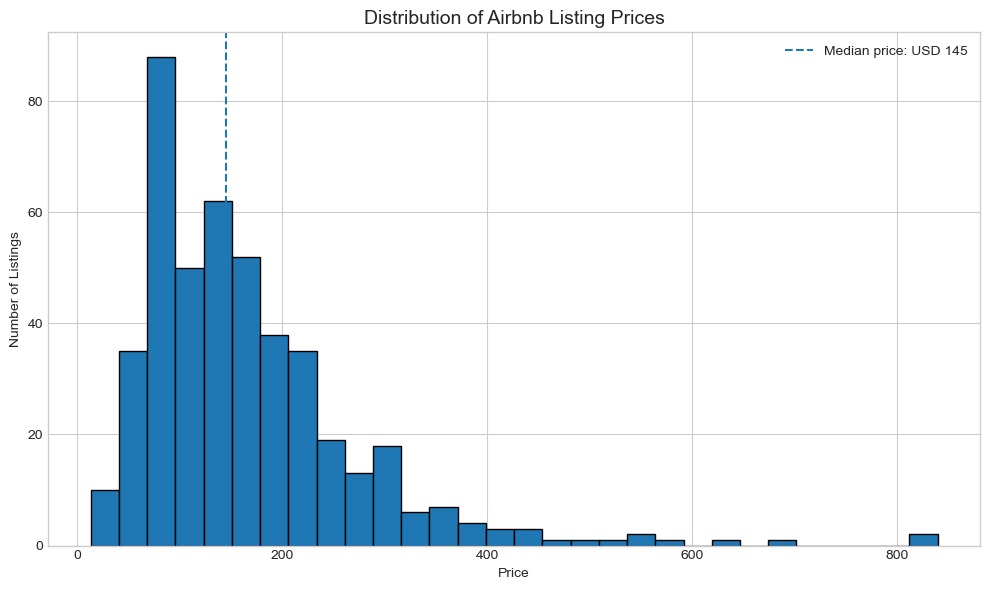

In [10]:
# Visualization 1: Price distribution

plt.figure(figsize=(10, 6))
plt.hist(airbnb["price"], bins=30, edgecolor="black")

plt.axvline(
    airbnb["price"].median(),
    linestyle="--",
    label=f"Median price: USD {airbnb['price'].median():,.0f}"
)

plt.title("Distribution of Airbnb Listing Prices", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.legend()

save_chart("01_price_distribution.png")

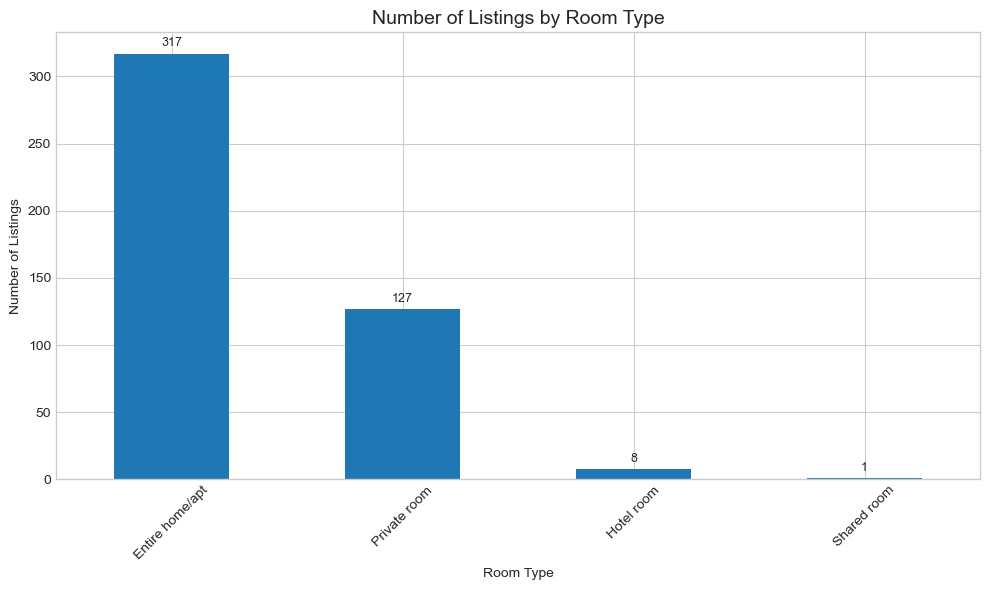

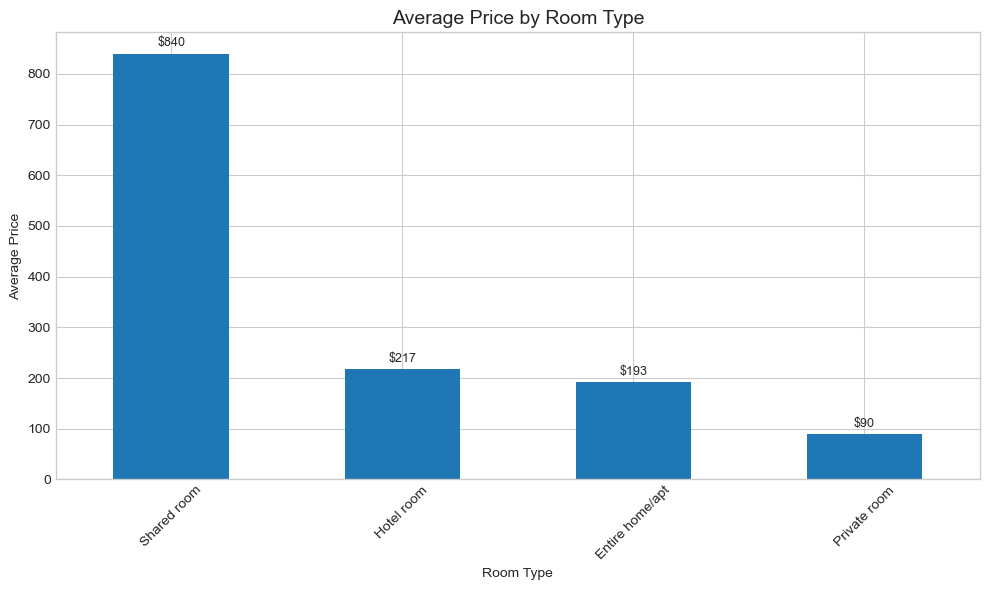

In [11]:
# Visualization 2: Room type counts

room_counts = airbnb["room_type"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
room_counts.plot(kind="bar", ax=ax)

ax.set_title("Number of Listings by Room Type", fontsize=14)
ax.set_xlabel("Room Type")
ax.set_ylabel("Number of Listings")
ax.tick_params(axis="x", rotation=45)

add_bar_labels(ax)

save_chart("02_room_type_counts.png")


# Visualization 3: Average price by room type

average_price_by_room = (
    airbnb.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
average_price_by_room.plot(kind="bar", ax=ax)

ax.set_title("Average Price by Room Type", fontsize=14)
ax.set_xlabel("Room Type")
ax.set_ylabel("Average Price")
ax.tick_params(axis="x", rotation=45)

add_bar_labels(ax, money=True)

save_chart("03_average_price_by_room_type.png")

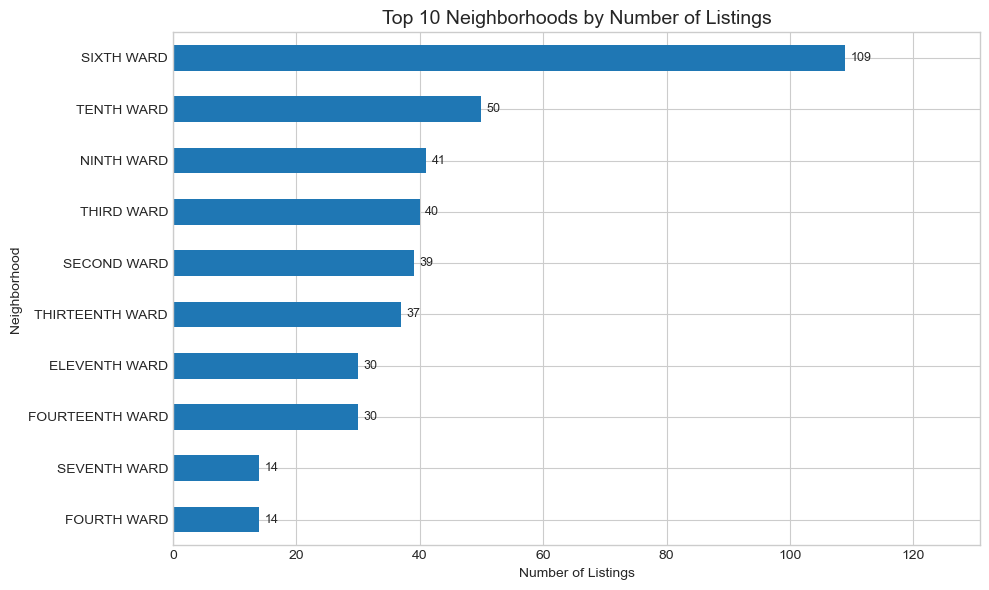

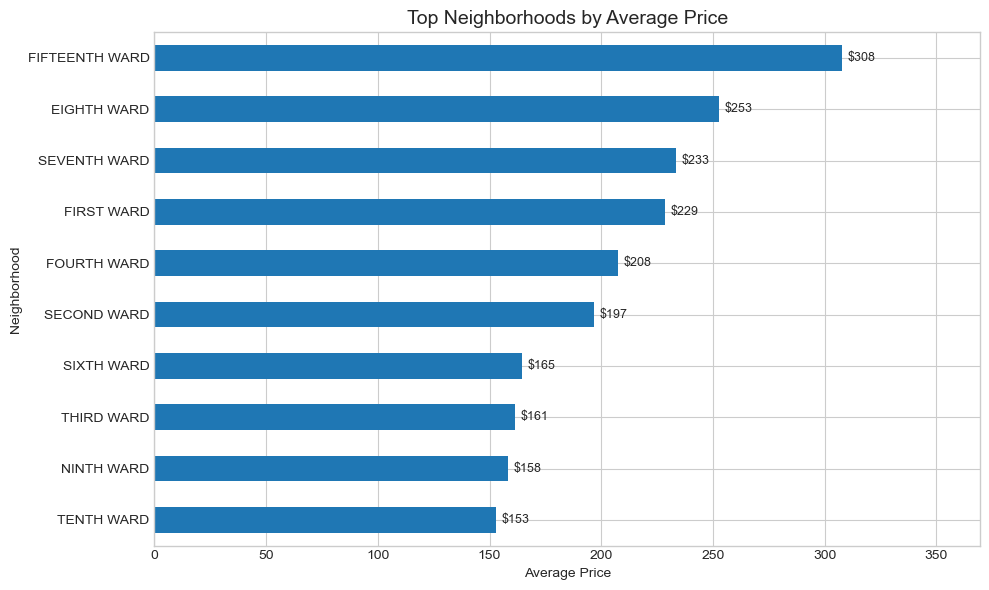

In [12]:
# Visualization 4: Top neighborhoods by listing count

top_neighborhood_counts = (
    airbnb["neighbourhood"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
top_neighborhood_counts.plot(kind="barh", ax=ax)

ax.set_title("Top 10 Neighborhoods by Number of Listings", fontsize=14)
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Neighborhood")

ax.set_xlim(0, top_neighborhood_counts.max() * 1.20)

add_barh_labels(ax)

save_chart("04_top_neighborhoods_by_listings.png")


# Visualization 5: Most expensive neighborhoods

neighborhood_price_visual = expensive_neighborhoods["average_price"].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
neighborhood_price_visual.plot(kind="barh", ax=ax)

ax.set_title("Top Neighborhoods by Average Price", fontsize=14)
ax.set_xlabel("Average Price")
ax.set_ylabel("Neighborhood")

ax.set_xlim(0, neighborhood_price_visual.max() * 1.20)

add_barh_labels(ax, money=True)

save_chart("05_top_neighborhoods_by_average_price.png")

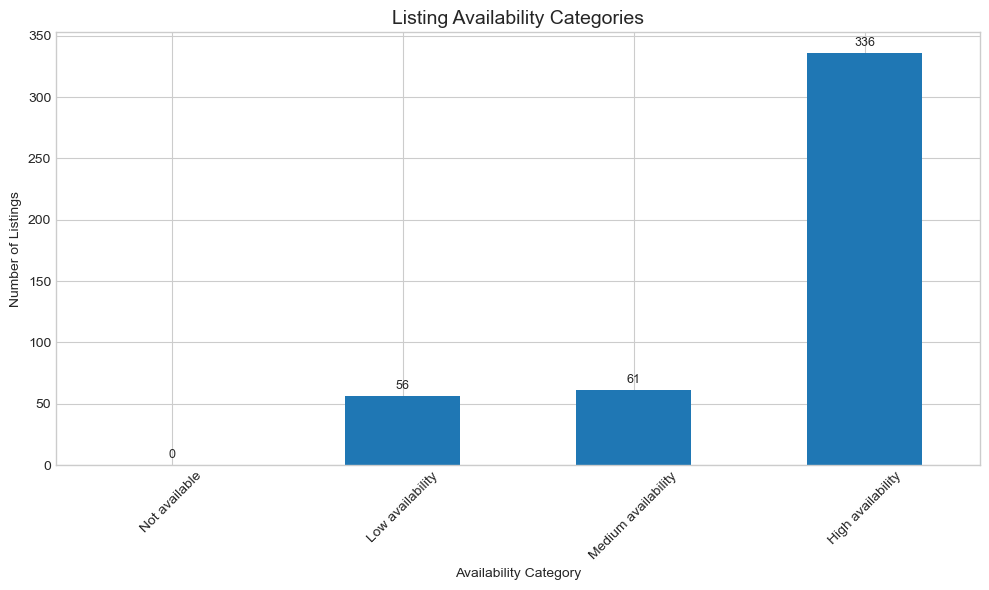

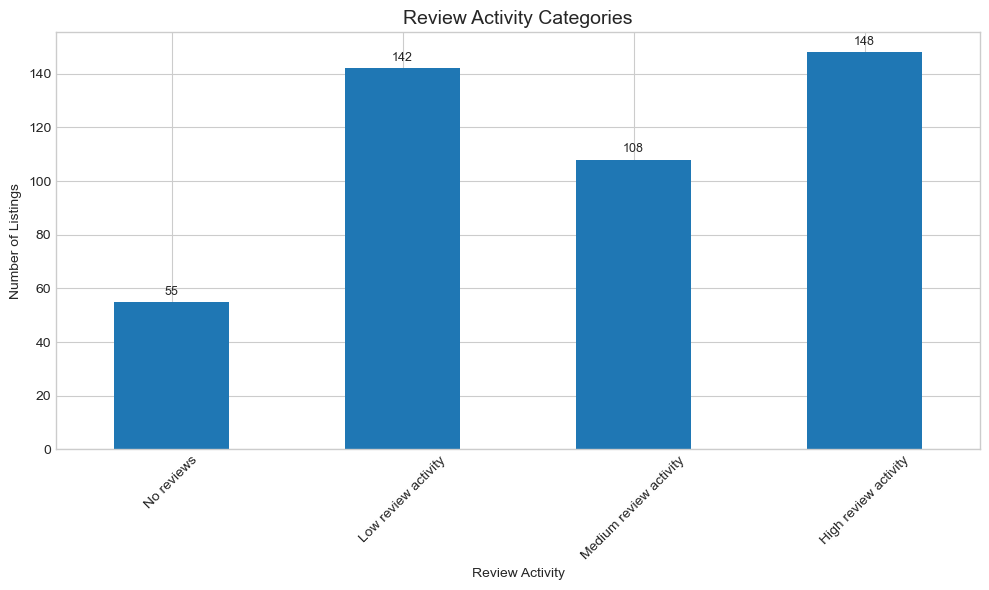

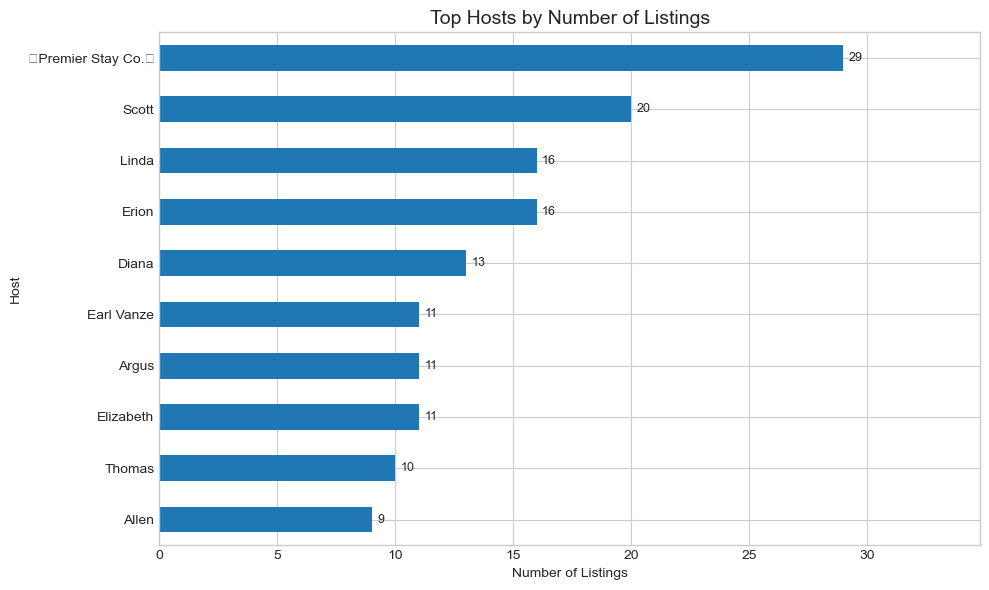

In [13]:
# Visualization 6: Availability categories

if "availability_category" in airbnb.columns:
    availability_counts = airbnb["availability_category"].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    availability_counts.plot(kind="bar", ax=ax)
    
    ax.set_title("Listing Availability Categories", fontsize=14)
    ax.set_xlabel("Availability Category")
    ax.set_ylabel("Number of Listings")
    ax.tick_params(axis="x", rotation=45)
    
    add_bar_labels(ax)
    
    save_chart("06_availability_categories.png")


# Visualization 7: Review activity categories

if "review_activity" in airbnb.columns:
    review_counts = airbnb["review_activity"].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    review_counts.plot(kind="bar", ax=ax)
    
    ax.set_title("Review Activity Categories", fontsize=14)
    ax.set_xlabel("Review Activity")
    ax.set_ylabel("Number of Listings")
    ax.tick_params(axis="x", rotation=45)
    
    add_bar_labels(ax)
    
    save_chart("07_review_activity_categories.png")


# Visualization 8: Top hosts by listing count

if "top_hosts" in globals():
    top_hosts_plot_data = top_hosts.reset_index()
    
    if "host_name" in top_hosts_plot_data.columns:
        top_hosts_plot_data["host_label"] = top_hosts_plot_data["host_name"].astype(str)
    else:
        top_hosts_plot_data["host_label"] = top_hosts_plot_data["host_id"].astype(str)
    
    top_hosts_plot = (
        top_hosts_plot_data
        .set_index("host_label")["listings"]
        .head(10)
        .sort_values()
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_hosts_plot.plot(kind="barh", ax=ax)
    
    ax.set_title("Top Hosts by Number of Listings", fontsize=14)
    ax.set_xlabel("Number of Listings")
    ax.set_ylabel("Host")
    
    ax.set_xlim(0, top_hosts_plot.max() * 1.20)
    
    add_barh_labels(ax)
    
    save_chart("08_top_hosts_by_listings.png")

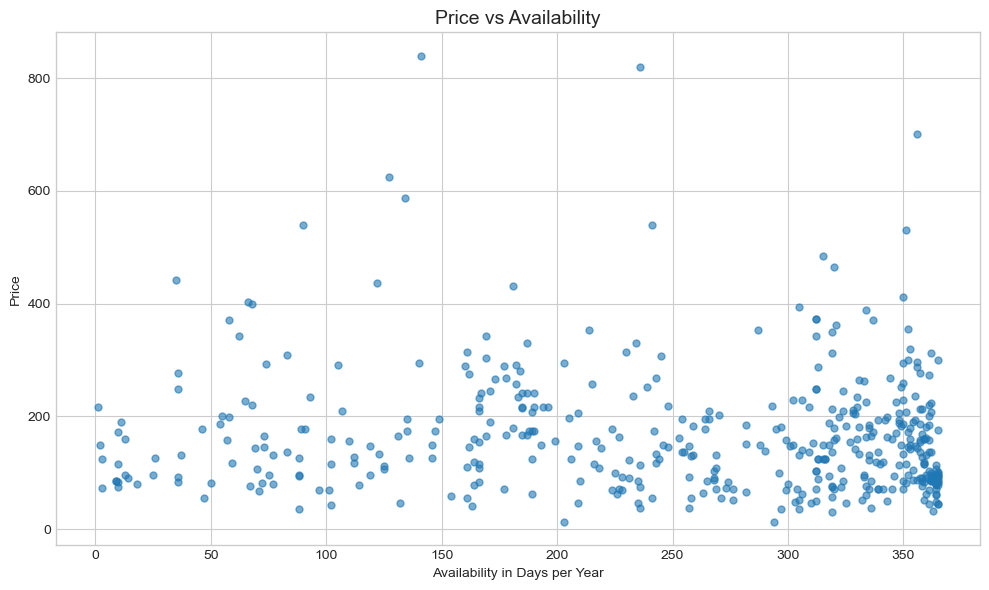

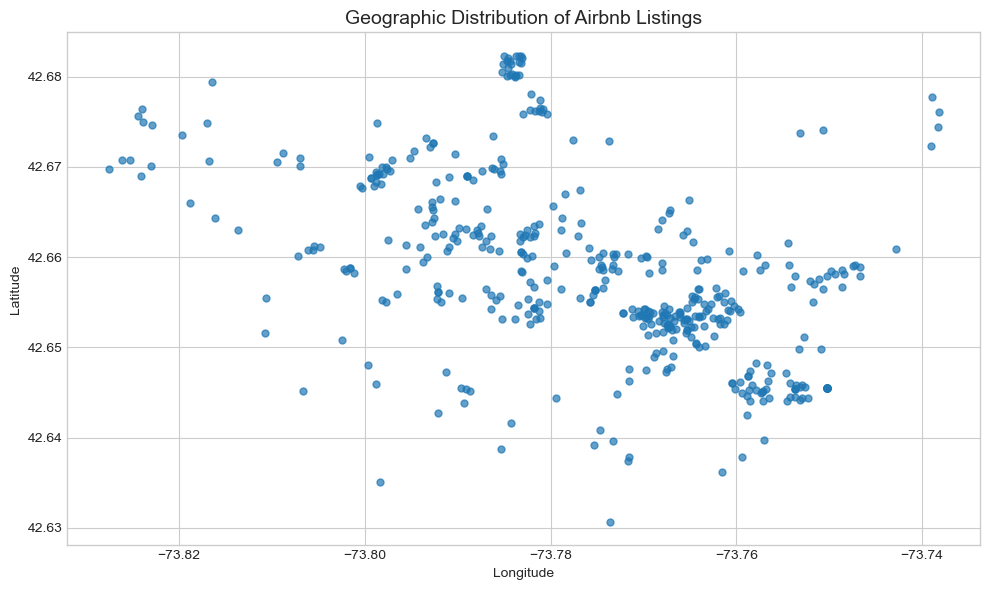

In [14]:
# Visualization 9: Price vs availability

if "availability_365" in airbnb.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(
        airbnb["availability_365"],
        airbnb["price"],
        alpha=0.6,
        s=25
    )
    
    plt.title("Price vs Availability", fontsize=14)
    plt.xlabel("Availability in Days per Year")
    plt.ylabel("Price")
    
    save_chart("09_price_vs_availability.png")


# Visualization 10: Geographic spread of listings

if {"longitude", "latitude"}.issubset(airbnb.columns):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        airbnb["longitude"],
        airbnb["latitude"],
        alpha=0.7,
        s=25
    )
    
    plt.title("Geographic Distribution of Airbnb Listings", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    save_chart("10_geographic_distribution.png")

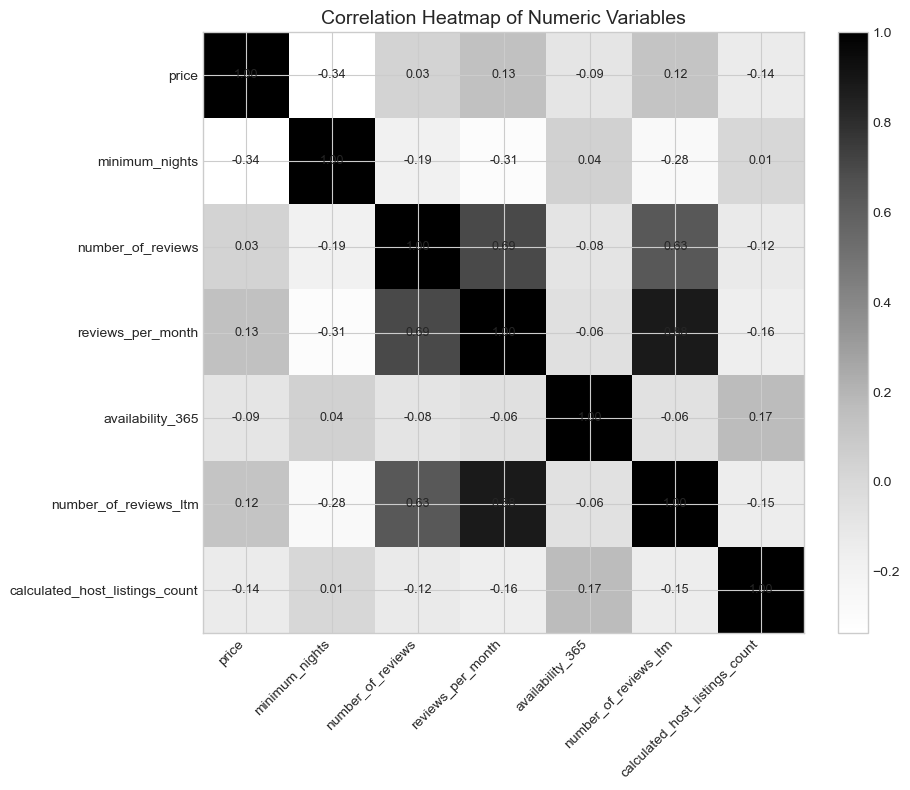

In [15]:
# Visualization 11: Correlation heatmap for numerical columns

correlation_columns = [
    col for col in [
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "availability_365",
        "number_of_reviews_ltm",
        "calculated_host_listings_count"
    ]
    if col in airbnb.columns
]

correlation_matrix = airbnb[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix)

ax.set_title("Correlation Heatmap of Numeric Variables", fontsize=14)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))

ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

# Add correlation values inside the heatmap
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

save_chart("11_correlation_heatmap.png")

# Project Limitations

This analysis is based on a single Airbnb listings dataset, so the results describe the listings available in this file rather than the entire short-term rental market.

Some columns had missing values. The `neighbourhood_group` and `license` columns were fully empty and were removed during cleaning. Listings without valid prices were excluded, and extreme price outliers were capped using the 99th percentile to make the price analysis more reliable.

Room types or neighborhoods with very few listings should be interpreted carefully because a small number of listings can strongly affect averages.

# Business Recommendations

Based on the analysis:

1. Hosts can compare their listing prices with the median price of similar room types to avoid overpricing.
2. Areas with high listing counts may have stronger competition, so hosts in those neighborhoods should focus on reviews, availability, and listing quality.
3. Neighborhoods with higher average prices may represent premium areas, but they should be interpreted alongside listing count and room type.
4. Listings with high availability may need pricing or marketing adjustments if they are not receiving enough reviews.
5. Travelers can use room type and neighborhood trends to find better-value stays based on their budget.

In [16]:
# Final project conclusion and export

cleaned_csv_path = Path("cleaned_airbnb_listings.csv")
airbnb.to_csv(cleaned_csv_path, index=False)

saved_visuals = sorted([file.name for file in VISUALS_DIR.glob("*.png")])

final_average_price = airbnb["price"].mean()
final_median_price = airbnb["price"].median()
final_top_room_type = room_type_summary.index[0]
final_top_neighborhood = neighborhood_summary.index[0]
final_highest_price_neighborhood = expensive_neighborhoods.index[0]

display(Markdown(f"""
# Final Project Conclusion

This project completed **Task 2: Exploratory Data Analysis** and **Task 3: Data Visualization** for the CodeAlpha Data Analytics internship.

## Main Insights

- The cleaned dataset contains **{airbnb.shape[0]:,} Airbnb listings**.
- The average listing price is **USD {final_average_price:,.2f}**.
- The median listing price is **USD {final_median_price:,.2f}**.
- The most common room type is **{final_top_room_type}**.
- The neighborhood with the most listings is **{final_top_neighborhood}**.
- The highest average price among neighborhoods with enough listings appears in **{final_highest_price_neighborhood}**.
- The analysis shows that Airbnb prices vary based on room type, neighborhood, availability, and host behavior.

## Files Created

- Cleaned dataset: `cleaned_airbnb_listings.csv`
- Visualization folder: `visuals/`

## Portfolio Summary

This project demonstrates data cleaning, exploratory data analysis, feature creation, grouped analysis, outlier handling, and data visualization using Python, Pandas, NumPy, and Matplotlib.
"""))

display(Markdown("## Saved Visual Files"))
display(pd.DataFrame({"visual_file": saved_visuals}))

print("Cleaned dataset saved to:", cleaned_csv_path)
print("Visuals saved in folder:", VISUALS_DIR)


# Final Project Conclusion

This project completed **Task 2: Exploratory Data Analysis** and **Task 3: Data Visualization** for the CodeAlpha Data Analytics internship.

## Main Insights

- The cleaned dataset contains **453 Airbnb listings**.
- The average listing price is **USD 165.62**.
- The median listing price is **USD 145.00**.
- The most common room type is **Entire home/apt**.
- The neighborhood with the most listings is **SIXTH WARD**.
- The highest average price among neighborhoods with enough listings appears in **FIFTEENTH WARD**.
- The analysis shows that Airbnb prices vary based on room type, neighborhood, availability, and host behavior.

## Files Created

- Cleaned dataset: `cleaned_airbnb_listings.csv`
- Visualization folder: `visuals/`

## Portfolio Summary

This project demonstrates data cleaning, exploratory data analysis, feature creation, grouped analysis, outlier handling, and data visualization using Python, Pandas, NumPy, and Matplotlib.


## Saved Visual Files

,visual_file
0,01_price_distribution.png
1,02_room_type_counts.png
2,03_average_price_by_room_type.png
3,04_top_neighborhoods_by_listings.png
4,05_top_neighborhoods_by_average_price.png
5,06_availability_categories.png
6,07_review_activity_categories.png
7,08_top_hosts_by_listings.png
8,09_price_vs_availability.png
9,10_geographic_distribution.png


Cleaned dataset saved to: cleaned_airbnb_listings.csv
Visuals saved in folder: visuals
